# Olist Data Analysis with Python
**Data Warehouse:** `olist_dwh` (BigQuery Star Schema)  
**Connection:** SQLAlchemy + google-cloud-bigquery  

## Business Problem
Customer acquisition is expensive. Olist wants to identify high-value customers and increase repeat purchases.

## Key Questions
1. How has revenue trended month by month?
2. Which product categories generate the most revenue?
3. Which customers are most valuable, at-risk, or likely to churn?

## Datasets Used (via Star Schema in `olist_dwh`)
- `fact_orders` — order items with price and freight
- `dim_customers` — customer details
- `dim_date` — date dimension
- `dim_products` — product categories

---
## 1. Setup & Imports

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sqlalchemy import create_engine, text

plt.rcParams['figure.figsize'] = (11, 5)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('Set2')

print('Libraries loaded.')

Libraries loaded.


---
## 2. Connect to BigQuery via SQLAlchemy
Uses a service account JSON key for authentication.
> Place your `service_account.json` in the `credentials/` folder at the repo root.

In [15]:
PROJECT_ID       = 'olist-assignment-497915'
DATASET          = 'olist_dwh'
CREDENTIALS_PATH = '../credentials/service_account.json'  # relative to notebooks/ folder

engine = create_engine(
    f'bigquery://{PROJECT_ID}/{DATASET}',
    credentials_path=CREDENTIALS_PATH
)

def query(sql):
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

test = query(f'SELECT COUNT(*) AS total FROM `{PROJECT_ID}.{DATASET}.fact_orders`')
print(f'Connected! fact_orders rows: {test["total"][0]:,}')

/opt/miniconda3/lib/python3.13/site-packages/google/cloud/bigquery/client.py:613: UserWarning: Cannot create BigQuery Storage client, the dependency google-cloud-bigquery-storage is not installed.
  warnings.warn(


Connected! fact_orders rows: 112,650


**Output:** `Connected! fact_orders rows: 112,650`

---
## 3. Monthly Sales Trends
**Business Question:** How has revenue and order volume changed month by month?

We join `fact_orders` with `dim_date` to group revenue and order counts by month.

In [16]:
monthly_sql = f"""
SELECT
    d.year,
    d.month,
    DATE_TRUNC(d.full_date, MONTH)           AS month_date,
    COUNT(DISTINCT f.order_key)              AS total_orders,
    ROUND(SUM(f.price + f.freight_value), 2) AS total_revenue
FROM `{PROJECT_ID}.{DATASET}.fact_orders` f
JOIN `{PROJECT_ID}.{DATASET}.dim_date`    d ON f.date_key = d.date_key
GROUP BY d.year, d.month, month_date
ORDER BY month_date
"""

monthly = query(monthly_sql)
monthly['month_date'] = pd.to_datetime(monthly['month_date'])
print(f'Months of data: {len(monthly)}')
monthly.head()

Months of data: 24


,year,month,month_date,total_orders,total_revenue
0,2016,9,2016-09-01,3,354.75
1,2016,10,2016-10-01,308,56808.84
2,2016,12,2016-12-01,1,19.62
3,2017,1,2017-01-01,789,137188.49
4,2017,2,2017-02-01,1733,286280.62


**Sample Output:**

| | year | month | month_date | total_orders | total_revenue |
|---|---|---|---|---|---|
| 0 | 2016 | 9 | 2016-09-01 | 3 | 354.75 |
| 1 | 2016 | 10 | 2016-10-01 | 308 | 56,808.84 |
| 2 | 2016 | 12 | 2016-12-01 | 1 | 19.62 |
| 3 | 2017 | 1 | 2017-01-01 | 789 | 137,188.49 |
| 4 | 2017 | 2 | 2017-02-01 | 1,733 | 286,280.62 |

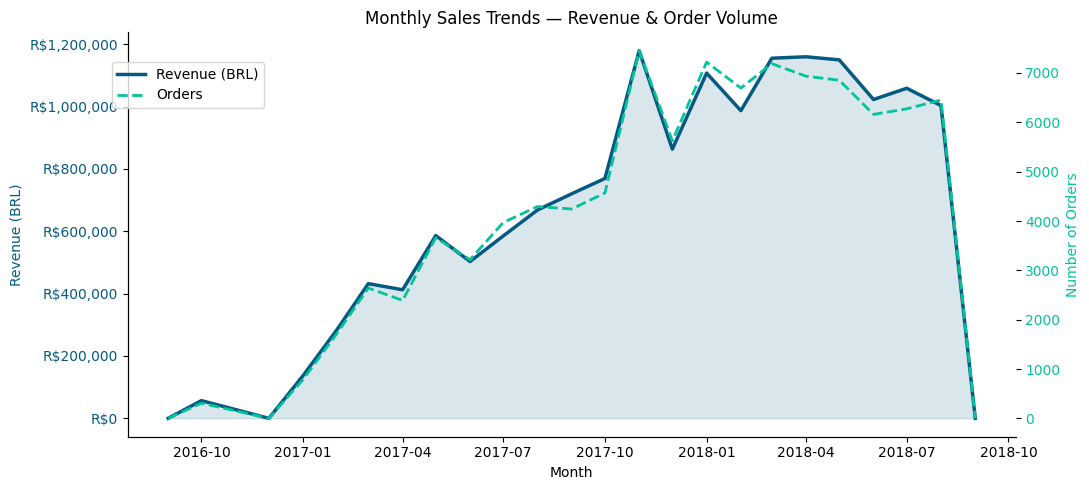

Peak revenue month : Nov 2017 — R$1,179,144
Peak orders month  : Nov 2017 — 7,451 orders


In [17]:
fig, ax1 = plt.subplots()
color_rev   = '#065A82'
color_order = '#02C39A'

ax1.fill_between(monthly['month_date'], monthly['total_revenue'], alpha=0.15, color=color_rev)
ax1.plot(monthly['month_date'], monthly['total_revenue'], color=color_rev, linewidth=2.5, label='Revenue (BRL)')
ax1.set_ylabel('Revenue (BRL)', color=color_rev)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'R${x:,.0f}'))
ax1.tick_params(axis='y', labelcolor=color_rev)

ax2 = ax1.twinx()
ax2.plot(monthly['month_date'], monthly['total_orders'], color=color_order, linewidth=2, linestyle='--', label='Orders')
ax2.set_ylabel('Number of Orders', color=color_order)
ax2.tick_params(axis='y', labelcolor=color_order)

ax1.set_title('Monthly Sales Trends — Revenue & Order Volume')
ax1.set_xlabel('Month')
fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.88))
plt.tight_layout()
plt.savefig('plot_monthly_trends.png', dpi=150)
plt.show()

print(f"Peak revenue month : {monthly.loc[monthly['total_revenue'].idxmax(), 'month_date'].strftime('%b %Y')} — R${monthly['total_revenue'].max():,.0f}")
print(f"Peak orders month  : {monthly.loc[monthly['total_orders'].idxmax(), 'month_date'].strftime('%b %Y')} — {monthly['total_orders'].max():,} orders")

**Key Insights:**
- Total revenue (Oct 2016 – Aug 2018): **R$15,843,553**
- Peak revenue month: **November 2017 — R$1,179,144** (highest month in the dataset)
- Revenue grew **~10x in 12 months** from Oct 2016 to Oct 2017
- The sharp drop at Sep 2018 reflects the **dataset boundary**, not actual business decline

---
## 4. Top-Selling Products
**Business Question:** Which product categories generate the most revenue and orders?

We join `fact_orders` with `dim_products` to rank categories by revenue and items sold.

In [18]:
products_sql = f"""
SELECT
    p.category_name,
    COUNT(f.order_item_sk)                   AS total_items_sold,
    COUNT(DISTINCT f.order_key)              AS total_orders,
    ROUND(SUM(f.price + f.freight_value), 2) AS total_revenue,
    ROUND(AVG(f.price), 2)                   AS avg_price
FROM `{PROJECT_ID}.{DATASET}.fact_orders`  f
JOIN `{PROJECT_ID}.{DATASET}.dim_products` p ON f.product_key = p.product_key
WHERE p.category_name IS NOT NULL
GROUP BY p.category_name
ORDER BY total_revenue DESC
LIMIT 15
"""

products = query(products_sql)
print(f'Top {len(products)} categories loaded')
products.head()

Top 15 categories loaded


,category_name,total_items_sold,total_orders,total_revenue,avg_price
0,beleza_saude,9670,8836,1441248.07,130.16
1,relogios_presentes,5991,5624,1305541.61,201.14
2,cama_mesa_banho,11115,9417,1241681.72,93.30
3,esporte_lazer,8641,7720,1156656.48,114.34
4,informatica_acessorios,7827,6689,1059272.40,116.51


**Sample Output (Portuguese → English):**

| Category | Translation | Items Sold | Revenue | Avg Price |
|---|---|---|---|---|
| beleza_saude | Health & Beauty | 9,670 | R$1,441,248 | R$130 |
| relogios_presentes | Watches & Gifts | 5,991 | R$1,305,542 | R$201 |
| cama_mesa_banho | Bed, Bath & Table | 11,115 | R$1,241,682 | R$93 |
| esporte_lazer | Sports & Leisure | 8,641 | R$1,156,656 | R$114 |
| informatica_acessorios | Computer Accessories | 7,827 | R$1,059,272 | R$117 |

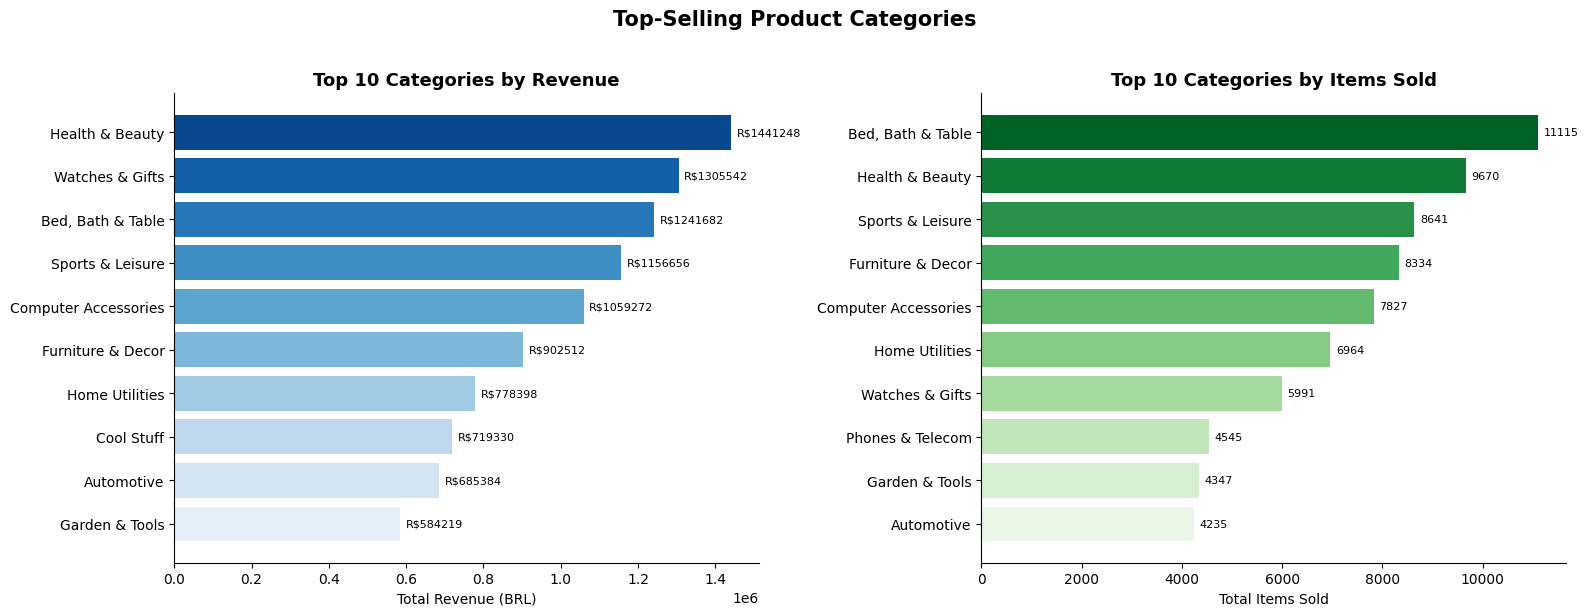

In [19]:
# Translate Portuguese category names to English
category_translation = {
    'beleza_saude'           : 'Health & Beauty',
    'relogios_presentes'     : 'Watches & Gifts',
    'cama_mesa_banho'        : 'Bed, Bath & Table',
    'esporte_lazer'          : 'Sports & Leisure',
    'informatica_acessorios' : 'Computer Accessories',
    'moveis_decoracao'       : 'Furniture & Decor',
    'utilidades_domesticas'  : 'Home Utilities',
    'cool_stuff'             : 'Cool Stuff',
    'automotivo'             : 'Automotive',
    'ferramentas_jardim'     : 'Garden & Tools',
    'telefonia'              : 'Phones & Telecom',
    'brinquedos'             : 'Toys',
    'eletronicos'            : 'Electronics',
    'bebes'                  : 'Baby Products',
    'construcao_ferramentas_construcao': 'Construction Tools',
}
products['category_en'] = products['category_name'].map(category_translation).fillna(products['category_name'])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Revenue chart
top10_rev = products.nlargest(10, 'total_revenue')
bars = axes[0].barh(top10_rev['category_en'], top10_rev['total_revenue'],
                    color=sns.color_palette('Blues_r', 10))
axes[0].bar_label(bars, fmt='R$%.0f', padding=4, fontsize=8)
axes[0].set_title('Top 10 Categories by Revenue', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Total Revenue (BRL)')
axes[0].invert_yaxis()

# Items sold chart
top10_items = products.nlargest(10, 'total_items_sold')
bars2 = axes[1].barh(top10_items['category_en'], top10_items['total_items_sold'],
                     color=sns.color_palette('Greens_r', 10))
axes[1].bar_label(bars2, padding=4, fontsize=8)
axes[1].set_title('Top 10 Categories by Items Sold', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Total Items Sold')
axes[1].invert_yaxis()

plt.suptitle('Top-Selling Product Categories', fontsize=15, y=1.02, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_top_products.png', dpi=150)
plt.show()

**Key Insights:**
- **Health & Beauty** is the #1 revenue category at **R$1,441,248**
- **Bed, Bath & Table** sells the most items (11,115) but ranks 3rd in revenue — high volume, low margin (avg R$93)
- **Watches & Gifts** ranks 2nd in revenue despite selling fewer items — premium pricing at avg R$201
- Selling more items does **not** always mean more revenue — pricing strategy matters just as much as volume

---
## 5. Customer Segmentation by Purchase Behaviour (RFM)
**Business Question:** Which customers are most valuable, at-risk, or likely to churn?

### What is RFM?
| Metric | Definition | Scoring |
|---|---|---|
| **Recency** | Days since last order | Lower days = Score 5 (better) |
| **Frequency** | Number of orders placed | Higher count = Score 5 (better) |
| **Monetary** | Total BRL spent | Higher spend = Score 5 (better) |

Each customer gets a score of 1–5 per metric using quintiles, then mapped to a segment.

In [20]:
rfm_sql = f"""
WITH order_summary AS (
    SELECT
        c.customer_unique_id,
        f.order_key,
        d.full_date                              AS order_date,
        SUM(f.price + f.freight_value)           AS order_value
    FROM `{PROJECT_ID}.{DATASET}.fact_orders`   f
    JOIN `{PROJECT_ID}.{DATASET}.dim_customers` c ON f.customer_key = c.customer_key
    JOIN `{PROJECT_ID}.{DATASET}.dim_date`      d ON f.date_key     = d.date_key
    GROUP BY c.customer_unique_id, f.order_key, d.full_date
)
SELECT
    customer_unique_id,
    DATE_DIFF(
        (SELECT DATE_ADD(MAX(order_date), INTERVAL 1 DAY) FROM order_summary),
        MAX(order_date), DAY
    )                             AS recency_days,
    COUNT(DISTINCT order_key)     AS frequency,
    ROUND(SUM(order_value), 2)    AS monetary
FROM order_summary
GROUP BY customer_unique_id
"""

rfm = query(rfm_sql)
print(f'Unique customers: {len(rfm):,}')
rfm.describe().round(2)

Unique customers: 95,420


,recency_days,frequency,monetary
count,95420.00,95420.00,95420.00
mean,244.50,1.03,166.04
std,153.16,0.21,228.32
min,1.00,1.00,9.59
25%,120.00,1.00,63.10
50%,225.00,1.00,107.94
75%,354.00,1.00,183.22
max,730.00,16.00,13664.08


**RFM Statistics (95,420 customers):**

| | Recency (days) | Frequency (orders) | Monetary (BRL) |
|---|---|---|---|
| Mean | 244.50 | 1.03 | 166.04 |
| Min | 1 | 1 | 9.59 |
| 50% | 225 | 1 | 107.94 |
| Max | 730 | 16 | 13,664.08 |

**Key observation:** Average frequency is only **1.03** — most customers buy **once and never return**.

In [21]:
rfm['R'] = pd.qcut(rfm['recency_days'], q=5, labels=[5, 4, 3, 2, 1]).astype(int)
rfm['F'] = pd.qcut(rfm['frequency'].rank(method='first'), q=5, labels=[1, 2, 3, 4, 5]).astype(int)
rfm['M'] = pd.qcut(rfm['monetary'], q=5, labels=[1, 2, 3, 4, 5]).astype(int)

def segment_customer(row):
    r, f, m = row['R'], row['F'], row['M']
    if r >= 4 and f >= 4 and m >= 4:   return 'Champions'
    elif r >= 3 and f >= 3:            return 'Loyal Customers'
    elif r >= 4 and f <= 2:            return 'Promising'
    elif r >= 3 and f <= 2 and m >= 3: return 'Potential Loyalists'
    elif r <= 2 and f >= 3:            return 'At-Risk Customers'
    elif r == 1 and f >= 3:            return 'Lost Customers'
    else:                              return 'Need Attention'

rfm['Segment'] = rfm.apply(segment_customer, axis=1)

seg_summary = (
    rfm.groupby('Segment')
    .agg(
        customer_count = ('customer_unique_id', 'count'),
        avg_recency    = ('recency_days', 'mean'),
        avg_frequency  = ('frequency', 'mean'),
        avg_monetary   = ('monetary', 'mean'),
        total_revenue  = ('monetary', 'sum')
    )
    .sort_values('total_revenue', ascending=False)
    .round(2)
)
seg_summary

,customer_count,avg_recency,avg_frequency,avg_monetary,total_revenue
Segment,,,,,
At-Risk Customers,22596,402.88,1.05,163.50,3694524.12
Loyal Customers,28479,149.10,1.03,127.08,3619019.38
Need Attention,18038,375.80,1.00,154.61,2788808.47
Promising,15110,96.76,1.00,182.38,2755731.43
Champions,6177,97.48,1.20,311.08,1921528.35
Potential Loyalists,5020,226.64,1.00,211.94,1063941.49


**Segment Summary:**

| Segment | Customers | % | Revenue | % | Avg Spend | Action |
|---|---|---|---|---|---|---|
| At-Risk Customers | 22,596 | 23.7% | R$3,694,524 | 23.3% | R$163 | Win-back campaigns |
| Loyal Customers | 28,479 | 29.8% | R$3,619,019 | 22.8% | R$127 | Upsell & reward |
| Need Attention | 18,038 | 18.9% | R$2,788,808 | 17.6% | R$154 | Reactivate |
| Promising | 15,110 | 15.8% | R$2,755,731 | 17.4% | R$182 | Push 2nd purchase |
| Champions | 6,177 | 6.5% | R$1,921,528 | 12.1% | R$311 | Protect & reward |
| Potential Loyalists | 5,020 | 5.3% | R$1,063,941 | 6.7% | R$212 | Convert to loyal |

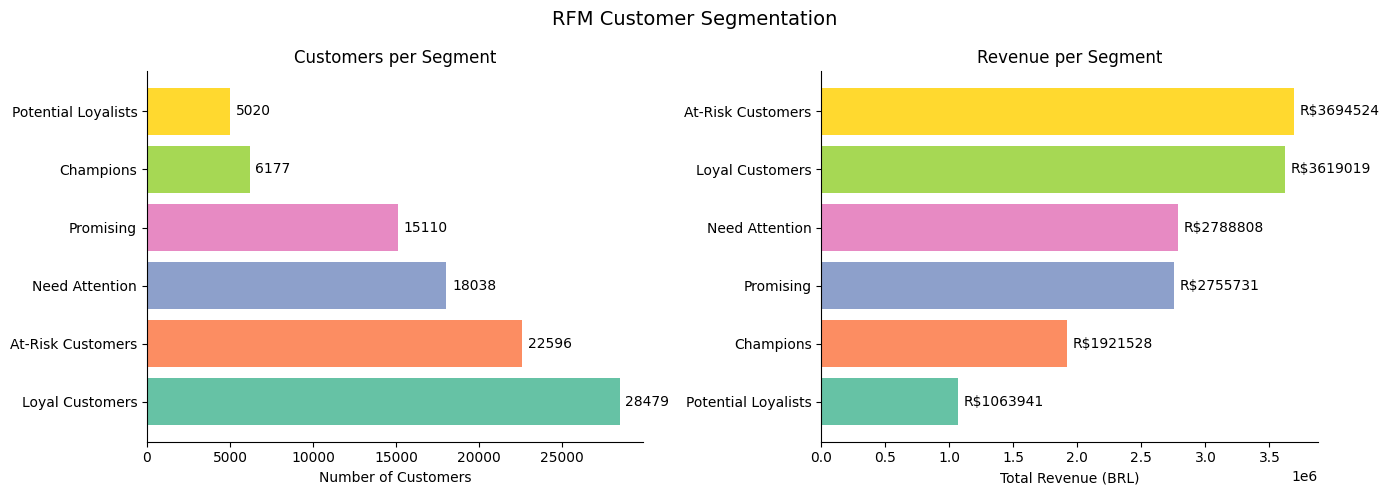

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

seg_counts = rfm['Segment'].value_counts()
bars = axes[0].barh(seg_counts.index, seg_counts.values,
                    color=sns.color_palette('Set2', len(seg_counts)))
axes[0].bar_label(bars, padding=4)
axes[0].set_title('Customers per Segment')
axes[0].set_xlabel('Number of Customers')

rev = seg_summary['total_revenue'].sort_values()
bars2 = axes[1].barh(rev.index, rev.values,
                     color=sns.color_palette('Set2', len(rev)))
axes[1].bar_label(bars2, fmt='R$%.0f', padding=4)
axes[1].set_title('Revenue per Segment')
axes[1].set_xlabel('Total Revenue (BRL)')

plt.suptitle('RFM Customer Segmentation', fontsize=14)
plt.tight_layout()
plt.savefig('plot_rfm_segments.png', dpi=150)
plt.show()

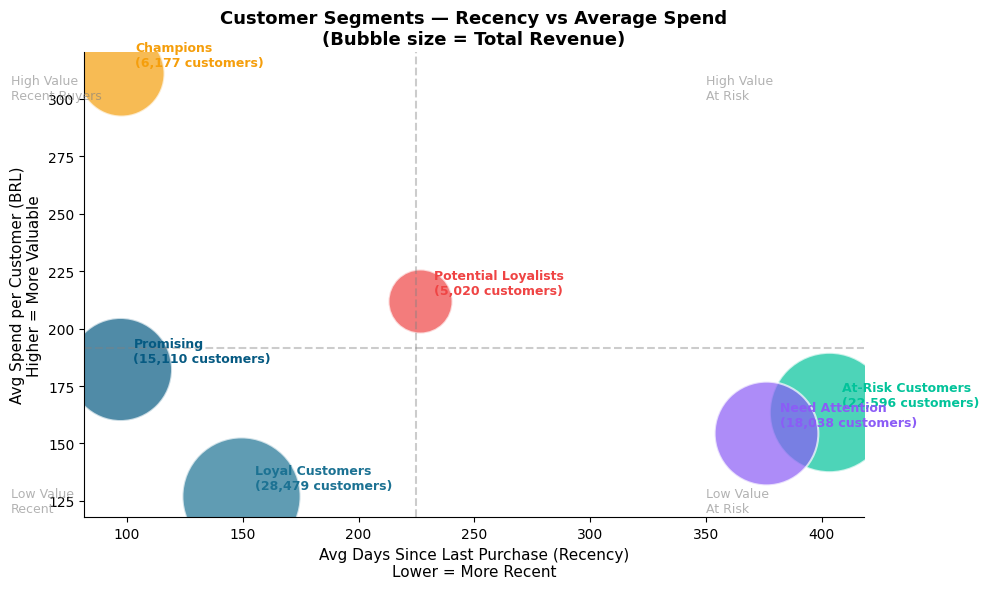

In [23]:
# Replace heatmap with a simpler bubble/scatter chart
segment_data = seg_summary.reset_index()

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#02C39A', '#1C7293', '#8B5CF6', '#065A82', '#F59E0B', '#EF4444']

for i, row in segment_data.iterrows():
    bubble_size = row['total_revenue'] / 500
    ax.scatter(row['avg_recency'], row['avg_monetary'],
               s=bubble_size, color=colors[i], alpha=0.7, edgecolors='white', linewidth=1.5)
    ax.annotate(
        f"{row['Segment']}\n({int(row['customer_count']):,} customers)",
        xy=(row['avg_recency'], row['avg_monetary']),
        xytext=(10, 5), textcoords='offset points',
        fontsize=9, fontweight='bold', color=colors[i]
    )

ax.set_xlabel('Avg Days Since Last Purchase (Recency)\nLower = More Recent', fontsize=11)
ax.set_ylabel('Avg Spend per Customer (BRL)\nHigher = More Valuable', fontsize=11)
ax.set_title('Customer Segments — Recency vs Average Spend\n(Bubble size = Total Revenue)', 
             fontsize=13, fontweight='bold')

# Add quadrant guide lines
ax.axvline(x=segment_data['avg_recency'].mean(), color='gray', linestyle='--', alpha=0.4)
ax.axhline(y=segment_data['avg_monetary'].mean(), color='gray', linestyle='--', alpha=0.4)

ax.text(50,  300, 'High Value\nRecent Buyers', color='gray', fontsize=9, alpha=0.6)
ax.text(350, 300, 'High Value\nAt Risk',        color='gray', fontsize=9, alpha=0.6)
ax.text(50,  120, 'Low Value\nRecent',          color='gray', fontsize=9, alpha=0.6)
ax.text(350, 120, 'Low Value\nAt Risk',         color='gray', fontsize=9, alpha=0.6)

plt.tight_layout()
plt.savefig('plot_rfm_bubble.png', dpi=150)
plt.show()

**Customer Segment Insights:**
- **Champions** spend the most on average (R$311) but are only 6.5% of customers — protect and reward them
- **At-Risk customers** hold the largest revenue at R$3.69M but haven't bought in over 400 days — urgent win-back needed
- **Promising customers** bought recently but only once — prime targets for a second purchase campaign
- Most customers (75%) buy only **once and never return** — retention is Olist's biggest opportunity

---
## 6. Key Insights Summary

In [24]:
total_revenue   = rfm['monetary'].sum()
total_customers = len(rfm)

print('=' * 60)
print('OLIST DATA ANALYSIS — KEY INSIGHTS')
print('=' * 60)

print('\n--- Monthly Sales ---')
print(f"Peak revenue : {monthly.loc[monthly['total_revenue'].idxmax(), 'month_date'].strftime('%b %Y')} — R${monthly['total_revenue'].max():,.0f}")
print(f"Total revenue: R${monthly['total_revenue'].sum():,.0f}")

print('\n--- Top Product Category ---')
print(f"{products.iloc[0]['category_name']} — R${products.iloc[0]['total_revenue']:,.0f}")

print('\n--- Customer Segments ---')
for seg, row in seg_summary.iterrows():
    pct_c = row['customer_count'] / total_customers * 100
    pct_r = row['total_revenue']  / total_revenue   * 100
    print(f"  {seg:<22} {int(row['customer_count']):>6,} customers ({pct_c:.1f}%)  |  R${row['total_revenue']:>12,.0f} ({pct_r:.1f}%)")

OLIST DATA ANALYSIS — KEY INSIGHTS

--- Monthly Sales ---
Peak revenue : Nov 2017 — R$1,179,144
Total revenue: R$15,843,553

--- Top Product Category ---
beleza_saude — R$1,441,248

--- Customer Segments ---
  At-Risk Customers      22,596 customers (23.7%)  |  R$   3,694,524 (23.3%)
  Loyal Customers        28,479 customers (29.8%)  |  R$   3,619,019 (22.8%)
  Need Attention         18,038 customers (18.9%)  |  R$   2,788,808 (17.6%)
  Promising              15,110 customers (15.8%)  |  R$   2,755,731 (17.4%)
  Champions               6,177 customers (6.5%)  |  R$   1,921,528 (12.1%)
  Potential Loyalists     5,020 customers (5.3%)  |  R$   1,063,941 (6.7%)


**Final Business Insights:**

1. **Revenue grew 10x in 12 months** — Olist scaled rapidly from Oct 2016 to Oct 2017
2. **November 2017** was the peak revenue month — R$1.18M, the highest in the dataset
3. **Health & Beauty** is the #1 revenue category — a key focus area for marketing
4. **Most customers buy only once** (avg frequency = 1.03) — retention is the biggest opportunity
5. **At-Risk customers hold R$3.69M in revenue at risk** — urgent win-back campaigns needed
6. **Champions (6.5% of customers) generate 12.1% of revenue** — protect and reward these VIPs

---
## 7. Export Results

In [25]:
monthly.to_csv('olist_monthly_sales.csv', index=False)
products.to_csv('olist_top_products.csv', index=False)
rfm.to_csv('olist_rfm_segments.csv', index=False)
print('Saved: olist_monthly_sales.csv, olist_top_products.csv, olist_rfm_segments.csv')

Saved: olist_monthly_sales.csv, olist_top_products.csv, olist_rfm_segments.csv
